# **Reporte escrito. Experimentos y análisis de estructuras de datos**
## **Alumno: Isaac Hernández Ramírez**

### **Introducción:**
La práctica de algoritmos para el manejo de matrices que haremos es fundamental en diversas áreas de la computación numérica, se compararon tres algoritmos clave: la multiplicación de matrices, la eliminación Gaussiana y el método de Gauss-Jordan, se evaluaron el número de operaciones y el tiempo de ejecución en matrices de diferentes tamaños (𝑛=100,300,1000), con el objetivo de analizar la eficiencia computacional de cada método. En términos de implementación eficiente, el manejo adecuado de las estructuras de datos y la organización de los accesos a memoria juegan un papel clave en el rendimiento computacional (Cormen et al., 2022, Cap. 10).

La multiplicación de matrices es una operación de complejidad
𝑂(𝑛3), aunque existen variantes más eficientes como el algoritmo de Strassen, que reduce la complejidad a aproximadamente 𝑂(𝑛2.81)(Cormen et al., 2022, Cap. 28). Sin embargo, para resolver sistemas de ecuaciones, la eliminación Gaussiana y el método de Gauss-Jordan son estrategias más eficientes en términos de costo computacional. En este sentido, la elección del algoritmo adecuado depende del tipo de problema que se quiera resolver y de la estructura de los datos.

Además, en la optimización de algoritmos matriciales, la organización de los accesos a memoria es determinante. Esto es particularmente relevante en arquitecturas modernas de cómputo, donde el acceso contiguo a memoria puede minimizar la latencia y maximizar la velocidad de procesamiento (Cormen et al., 2022, Cap. 22).


* Importamos librerías necesarias para hacer el ejercicio
    - Importamos numpy (para las operaciones con matrices)
    - Importamos time  (para medir el tiempo de ejecución)
    - Importamos tqdm  (Esto es opcional, es solo para ver el avance de la ejecución)

* Definimos la función para el caso de multiplicación de Matrices
    - Asumiremos que las matrices seran cuadradas

* Definimos la función para el caso de eliminación de gaussiana
    - Asumimos que es una matríz cuadrada

* Definimos la función para el caso de eliminación de gauss-jordan
    - Asumimos que es una matríz cuadrada

* Por fines prácticos almacenamos lo resultados de diccionarios

* Mostramos gráficas y resultados


1. Implementa los siguientes algoritmos sobre matrices.


     - Multiplicación de matrices

     - Eliminación gaussiana / Gauss-Jordan



2. Compara los desempeños de ambos algoritmos contando el número de operaciones y el tiempo real para matrices aleatorias de tamaño n×n
 para n=100,300,1000.

In [ ]:
# Librerias
import numpy as np
import time
from tqdm import tqdm

# definimos la función para la multiplicación de matrices
def matrix_multiplication(A, B):
    """Multiplica dos matrices A y B y cuenta el número de operaciones.

    Args:
    A: La primera matriz.
    B: La segunda matriz.

    Return:
    Matriz resultante, número de multiplicaciones, número de sumas, tiempo de ejecución.
    """
    n = A.shape[0] #.............................definimos el tamaño de las matrices (arreglos)
    C = np.zeros((n, n)) # ......................Se incializa la matriz resultante (C) en ceros
    multiplications = 0 # .......................contador para multiplicaciones (multiplications)
    additions = 0 # .............................contadors para las sumas (additions)
    start_time = time.time() # ..................guardamos el tiempo de ejecución


    #Hacemos las iteraciones de filas y columnas
    for i in tqdm(range(n), desc="Filas"): #..............filas de A
        for j in range(n): # .............................columnas B
            for k in range(n): # .........................iteramos sobre las columnas de A y las filas de B
                C[i, j] += A[i, k] * B[k, j] # ...........operaciones de suma y multiplicación
                multiplications += 1 # ...................icremento de contador mmultiplications
                if k > 0:
                    additions += 1 #......................incremento de contador additions

    end_time = time.time() # .............................guardamos el tiempo en que finaliza el proceso
    execution_time = end_time - start_time # .............tiempo total de ejecución

    return C, multiplications, additions, execution_time # retorno de matriz y contadores



# diccionario para almacenar los resultados de las multiplicaciones
multiplicacion = {}

# ejecutamos para diferentes tamaños de matriz con seguimiento del progreso (100,300 y 1000)
for idx, n in enumerate([100, 300, 1000]):
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    C, multiplications, additions, execution_time = matrix_multiplication(A, B)

    # guardamos los resultados en el diccionario que definimos antes
    multiplicacion[idx] = {
        "n": n,
        "multiplications": multiplications,
        "additions": additions,
        "execution_time": execution_time
    }

    # mostramos el progreso (por fines prácticos y análisis)
    print(f"Progreso: {((idx + 1) / 3) * 100:.2f}% completado")

Filas: 100%|██████████| 100/100 [00:00<00:00, 139.71it/s]


Progreso: 33.33% completado


Filas: 100%|██████████| 300/300 [00:17<00:00, 16.77it/s]


Progreso: 66.67% completado


Filas: 100%|██████████| 1000/1000 [11:27<00:00,  1.45it/s]

Progreso: 100.00% completado


In [ ]:
# definimos la función para eliminación de gauss
def gaussian_elimination(A):
    """Realiza la eliminación Gaussiana y cuenta el número de operaciones.

    Args:
    A: La matriz a la que se le aplicará la eliminación Gaussiana.

    Return:
    Matriz resultante, número de multiplicaciones, número de sumas, tiempo de ejecución.
    """
    n = A.shape[0]  # ...........................definimos el tamaño de las matrices (arreglos)
    multiplications = 0  # ......................contador de multiplicaciones (multiplications)
    additions = 0  # ......................contador de sumas (additions)
    start_time = time.time()  # ..................guardamos el tiempo de ejecución

    for i in tqdm(range(n), desc="Filas"):  #..............filas de A
        # Hacer el elemento A[i, i] igual a 1
        pivot = A[i, i]
        for j in range(i, n):  #..............columnas de A
            if A[i, j] != 0:
                A[i, j] /= pivot
                multiplications += 1

        # Hacer los elementos de la columna i, debajo de A[i, i], iguales a 0
        for k in range(i + 1, n):   # ..............................iteramos filas de A desde i
            factor = A[k, i]
            for j in range(i, n):  # ...............................iteramos columnas de A desde i
                A[k, j] -= factor * A[i, j]
                additions += 1
                if A[i, j] != 0:
                    multiplications += 1

    end_time = time.time()  # ...................guardamos el tiempo en que finaliza el proceso
    execution_time = end_time - start_time  # .............tiempo total de ejecución

    return A, multiplications, additions, execution_time   # retorno de matriz y contadores

# diccionario para almacenar los resultados de la eliminación Gaussiana
eliminacion_gauss = {}

# ejecutamos para diferentes tamaños de matriz con seguimiento del progreso (100, 300 y 1000)
for idx, n in enumerate([100, 300, 1000]):
    A = np.random.rand(n, n)
    A, multiplications, additions, execution_time = gaussian_elimination(A)

    # guardamos los resultados en el diccionario que definimos antes
    eliminacion_gauss[idx] = {
        "n": n,
        "multiplications": multiplications,
        "additions": additions,
        "execution_time": execution_time
    }

    # mostramos el progreso (por fines prácticos y análisis)
    print(f"Progreso: {((idx + 1) / 3) * 100:.2f}% completado")

Filas: 100%|██████████| 100/100 [00:00<00:00, 431.21it/s]


Progreso: 33.33% completado


Filas: 100%|██████████| 300/300 [00:06<00:00, 46.58it/s] 


Progreso: 66.67% completado


Filas: 100%|██████████| 1000/1000 [03:58<00:00,  4.19it/s]

Progreso: 100.00% completado


In [ ]:
# definimos la función para eliminación gaussiana
def gauss_jordan_elimination(A):
    """Realiza la eliminación gaussiana con el método de Gauss-Jordan y cuenta el número de operaciones.

    Args:
    A: La matriz a la que se le aplicará la eliminación gaussiana.

    Return:
    Matriz resultante, número de multiplicaciones, número de sumas, tiempo de ejecución.
    """
    n = A.shape[0]  # ...........................definimos el tamaño de las matrices (arreglos)
    multiplications = 0  # ......................contador de multiplicaciones
    additions = 0  # .............................Contador de sumas
    start_time = time.time()  # ..................guardamos el tiempo de ejecución

    for i in tqdm(range(n), desc="Filas"):  #..............filas de A
        # Hacer el elemento A[i, i] igual a 1
        pivot = A[i, i]  # ................................metemos un pivoteo para la fila i
        for j in range(n):  # .,...........................columnas en A
            if A[i, j] != 0:
                A[i, j] /= pivot  # .......................dividimos cada elemento de la fila i por el pivote
                multiplications += 1  # ...................incremento de contador mmultiplications

        # Hacer los elementos de la columna i, excepto A[i, i], iguales a 0
        for k in range(n):  # ..............................iteramos filas de A
            if k != i:  # ..................................restringuimos la fila pivote
                factor = A[k, i]  # ........................obtenemos el factor de la fila k
                for j in range(n):  # .............................iteramos columnas de A
                    A[k, j] -= factor * A[i, j]  # ......restamos el producto del factor y el elemento correspondiente de la fila del pivote
                    additions += 1  #......................incremento de contador additions
                    if A[i, j] != 0:
                        multiplications += 1  # Incrementa el contador de multiplicaciones si el elemento no es cero

    end_time = time.time()  # .............................guardamos el tiempo en que finaliza el proceso
    execution_time = end_time - start_time  # .............tiempo total de ejecución

    return A, multiplications, additions, execution_time  # retorno de matriz y contadores


# diccionario para almacenar los resultados de la eliminación gaussiana
eliminacion = {}

# ejecutamos para diferentes tamaños de matriz con seguimiento del progreso (100,300 y 1000)
for idx, n in enumerate([100, 300, 1000]):
    A = np.random.rand(n, n)
    A, multiplications, additions, execution_time = gauss_jordan_elimination(A)

    # guardamos los resultados en el diccionario que definimos antes
    eliminacion[idx] = {
        "n": n,
        "multiplications": multiplications,
        "additions": additions,
        "execution_time": execution_time
    }

    # mostramos el progreso (por fines prácticos y análisis)
    print(f"Progreso: {((idx + 1) / 3) * 100:.2f}% completado")

Filas: 100%|██████████| 100/100 [00:00<00:00, 143.98it/s]


Progreso: 33.33% completado


Filas: 100%|██████████| 300/300 [00:18<00:00, 16.11it/s]


Progreso: 66.67% completado


Filas: 100%|██████████| 1000/1000 [11:41<00:00,  1.42it/s]

Progreso: 100.00% completado


3. Maneja de manera separada los datos de conteo de operaciones (multiplicaciones y sumas escalares) y las de tiempo real.


In [ ]:
import pandas as pd
# Creamos un dataframe con la info de los diccionarios
data = []
for idx in multiplicacion.keys():
    data.append([
        multiplicacion[idx]["n"],
        multiplicacion[idx]["multiplications"] + multiplicacion[idx]['additions'],
        multiplicacion[idx]["execution_time"],
        eliminacion_gauss[idx]["multiplications"] + eliminacion_gauss[idx]['additions'],
        eliminacion_gauss[idx]["execution_time"],
        eliminacion[idx]["multiplications"] + eliminacion[idx]['additions'],
        eliminacion[idx]["execution_time"]
    ])

df = pd.DataFrame(data, columns=[
    "Tamaño",
    "Operaciones Multiplicación de Matrices",
    "Tiempo Multiplicación de Matrices",
    "Operaciones Gauss",
    "Tiempo Gauss",
    "Operaciones Gauss-Jordan",
    "Tiempo Gauss-Jordan"
])

# mostramos el DataFrame
df

,Tamaño,Operaciones Multiplicación de Matrices,Tiempo Multiplicación de Matrices,Operaciones Gauss,Tiempo Gauss,Operaciones Gauss-Jordan,Tiempo Gauss-Jordan
0,100,1990000,0.741628,671650,0.235906,1495000,0.700069
1,300,53910000,17.891673,18044950,6.445393,40455000,18.622784
2,1000,1999000000,687.908043,667166500,238.529724,1499500000,701.887946


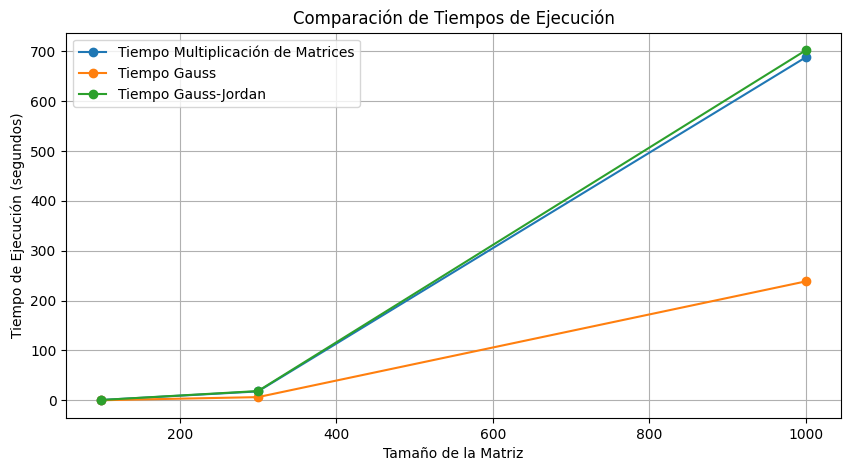

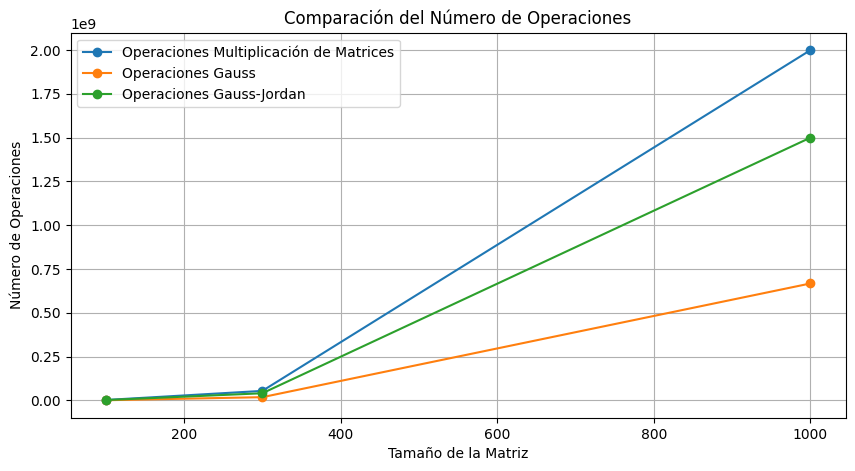

In [ ]:
import matplotlib.pyplot as plt

# graficamos los tiempos de ejecución de cada proceso
plt.figure(figsize=(10, 5))
plt.plot(df["Tamaño"], df["Tiempo Multiplicación de Matrices"], marker='o', label='Tiempo Multiplicación de Matrices')
plt.plot(df["Tamaño"], df["Tiempo Gauss"], marker='o', label='Tiempo Gauss')
plt.plot(df["Tamaño"], df["Tiempo Gauss-Jordan"], marker='o', label='Tiempo Gauss-Jordan')
plt.xlabel('Tamaño de la Matriz')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.title('Comparación de Tiempos de Ejecución')
plt.legend()
plt.grid(True)
plt.show()

# graficamos el número de operaciones de los procesos
plt.figure(figsize=(10, 5))
plt.plot(df["Tamaño"], df["Operaciones Multiplicación de Matrices"], marker='o', label='Operaciones Multiplicación de Matrices')
plt.plot(df["Tamaño"], df["Operaciones Gauss"], marker='o', label='Operaciones Gauss')
plt.plot(df["Tamaño"], df["Operaciones Gauss-Jordan"], marker='o', label='Operaciones Gauss-Jordan')
plt.xlabel('Tamaño de la Matriz')
plt.ylabel('Número de Operaciones')
plt.title('Comparación del Número de Operaciones')
plt.legend()
plt.grid(True)
plt.show()

### ✅ Discute los resultados experimentales:
¿Qué puedes concluir?
A partir de los resultados obtenidos, podemos extraer varias conclusiones clave:

* La cantidad de operaciones de la multiplicación de matrices es significativamente mayor que la de los métodos de eliminación Gaussiana y Gauss-Jordan, y su tiempo de ejecución es considerablemente más alto para la multiplicación de matrices en comparación con los otros métodos, en particular cuando  𝑛 aumenta.

* En operaciones el método Gauss-Jordan realiza más ciclos en el bucle que la eliminación Gaussiana, lo que explica su mayor tiempo de ejecución, esto se debe a que Gauss-Jordan no solo transforma la matriz en una forma triangular superior, sino que también la convierte en una matriz identidad, lo que requiere más pasos.

* Para 𝑛 = 1000, la multiplicación de matrices toma más de 687 segundos, un incremento drástico en comparación con los 0.74 segundos para 𝑛 = 100, este comportamiento también ocurre con la eliminación Gaussiana y Gauss-Jordan, aunque en tiempo menor la eliminación de gauss.

* Si tuvieramos una problematica que su objetivo sea resolver sistemas de ecuaciones lineales, la eliminación Gaussiana es más eficiente que la multiplicación de matrices en términos de tiempo de cómputo y operaciones requeridas, considerandola también más eficiente que Gauss-jordan.


¿Cuál es el impacto de acceder los elementos contiguos en memoria de una matriz?

* Este acceso a elementos continuos en memoria, es una factor de eifciencia computacional, debido a cómo las computadoras almacenan y recuperan datos de la RAM, la multiplicación de matrices accede a los elementos de manera menos eficiente en comparación a los otros métodos que pueden verse más optimizados (hablando en particular de la eliminación de gauss), en particular estas últimas dos realizan muchas operaciones fila por fila, pero generalemnet son más eficientes en términos de terminos de acceso a la memoria.

¿Qué cambiarías si utilizas matrices dispersas? ¿Cuáles serían los costos?

* Las matrices dispersas contienen muchos ceros, lo que nos permitiria usar estructuras de datos especiales para ahorrar memoria y mejorar la eficiencia computacional.
Osea que si por ejemplo usaramos scipy.sparse.csr_matrix en lugar del numpy, pues solo almacenariamos datos no nulos y eso correspondería a reducir el uso de la memoria, omitir operaciones incesarias por los ceros, para que fuesé más rápido el cálculo.
* Existen otras representaciones como la lista de coordenadas, coordinate lists (COO), o las representaciones dispersas compimidas, sparse row (CSR) y compressed sparse column (CSC) (Scott y Tůma 2023). Todas estas representaciones tratan de disminuir el uso de memoria y aprovechar la gran dispersión para realizar operaciones solo cuando sea estrictamente necesario.


### 📚 Referencias:

* Scott, Jennifer, and Miroslav Tůma. 2023. “An Introduction to Sparse Matrices.” In Algorithms for Sparse Linear Systems, 1–18. Cham: Springer International Publishing.
* Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). Introduction to Algorithms (4th ed.). MIT Press.
 - Cap. 10: Estructuras de datos y su impacto en la eficiencia computacional.
 -Cap. 22: Algoritmos elementales en grafos y su relación con el acceso a memoria.
 - Cap. 28: Algoritmos eficientes para operaciones matriciales, incluyendo la multiplicación de matrices.
